In [8]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import interpolate
from numpy import float64
import time

In [9]:
import sys
import os
import importlib


# Get the parent directory of the current file
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

import methods
importlib.reload(methods)
import solvers
importlib.reload(solvers)
import utils
importlib.reload(utils)

<module 'utils' from 'd:\\PhD at UCLA\\Allen-Cahn and Cahn-Hilliard\\Stabilized_RK_Allen_Cahn_Cahn_Hillard\\SRK\\utils.py'>

In [10]:
# Time and space range
a_x = 0
b_x = 2 * np.pi
a_y = 0
b_y = 2 * np.pi


s = 10

#Initial x grid size and t grid size
Nx = 512
Ny = 512

dx = float64((b_x - a_x) / Nx)
dy = float64((b_y - a_y) / Ny)

T = 8
eps = 0.1

# dt = 1 * dx**4 / eps**2
dt = 1e-1

bc= "Periodic"

save = True
save_path = "../../Results/Allen_Cahn_Comparison"


print("Initial dt used is " + str(dt))
print("eps used is " + str(eps))
print("4 * dt / dx^2 is " + str(4 * dt / dx**2))

Initial dt used is 0.1
eps used is 0.1
4 * dt / dx^2 is 2656.0740364736994


In [11]:
'''
Initial Condition for the Allen-Cahn simulation
'''
def initial_condition(mesh_grid):
    X, Y = mesh_grid
    return 0.05 * np.sin(X) * np.sin(Y)

In [12]:
method = "RKL2_2D"
# method = "RKG2_2D"

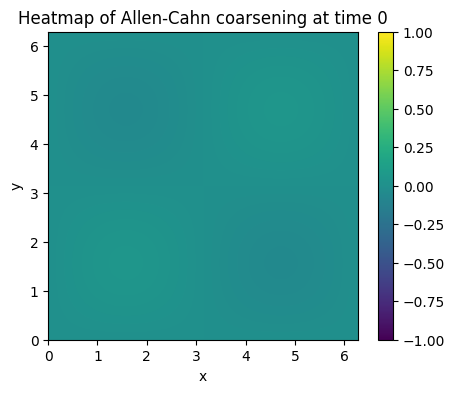

In [13]:
if method == "RKL2_2D":
    my_solver = solvers.Allen_Cahn_Solver_2D_Constant_Timestep("RKL2_2D", s, Nx, Ny, dt, dx, dy, a_x, b_x, a_y, b_y, initial_condition, T, eps, bc=bc, energy_case=3, plot_frequency=20, splitting_order="NLN", save=save, save_path=save_path)
elif method == "RKG2_2D":
    my_solver = solvers.Allen_Cahn_Solver_2D_Constant_Timestep("RKG2_2D", s, Nx, Ny, dt, dx, dy, a_x, b_x, a_y, b_y, initial_condition, T, eps, bc=bc, energy_case=3, plot_frequency=20, splitting_order="NLN", save=save, save_path=save_path)
else:
    raise ValueError("Invalid method")
    
my_solver.initialize(display=True)

Solving:   0%|                                                             | 0/81 [00:00<?, ?iter/s]

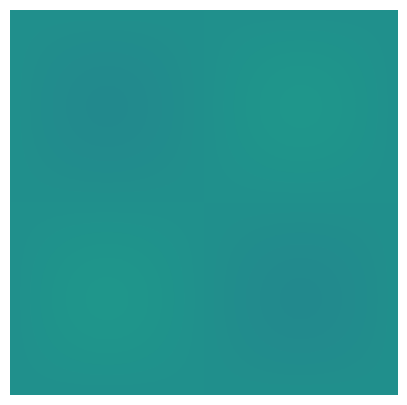

Max value of u_total[-1] is 0.05
Min value of u_total[-1] is -0.05


Solving:  25%|████████████▊                                       | 20/81 [00:07<00:21,  2.88iter/s]

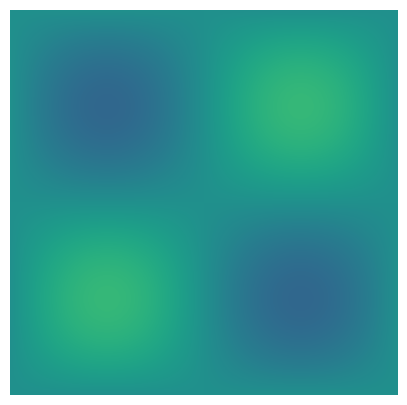

Max value of u_total[-1] is 0.33485192233590616
Min value of u_total[-1] is -0.33485192233590616


Solving:  49%|█████████████████████████▋                          | 40/81 [00:14<00:14,  2.91iter/s]

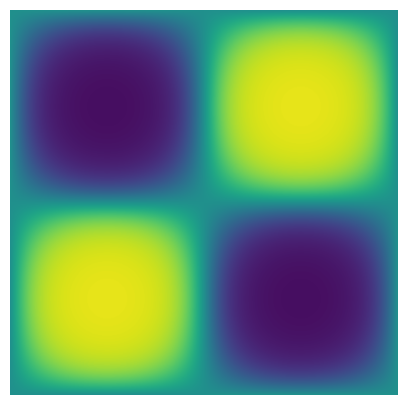

Max value of u_total[-1] is 0.9295051085877046
Min value of u_total[-1] is -0.9295051085877047


Solving:  74%|██████████████████████████████████████▌             | 60/81 [00:21<00:07,  2.84iter/s]

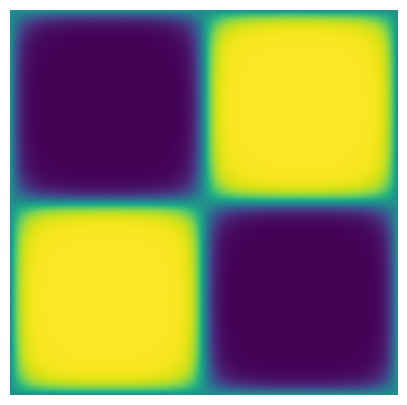

Max value of u_total[-1] is 0.9984252815214377
Min value of u_total[-1] is -0.9984252815214383


Solving:  99%|███████████████████████████████████████████████████▎| 80/81 [00:29<00:00,  2.75iter/s]

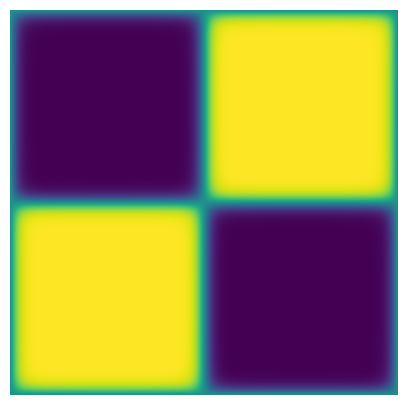

Max value of u_total[-1] is 0.9999678717069229
Min value of u_total[-1] is -0.9999678717069229


Solving: 100%|████████████████████████████████████████████████████| 81/81 [00:29<00:00,  2.72iter/s]


In [14]:
my_solver.solve()

In [15]:
u_total, t_total, energy_total, energy_modified_total, mesh_grid = my_solver.get_results()

Figure saved to ../../Results/Allen_Cahn_Comparison/RKL2_2D/RKL2_2D_AC_comparison_Nx512_Ny512_dt0.1_eps0.1000_T8_bcPeriodic_energy_case3.pdf


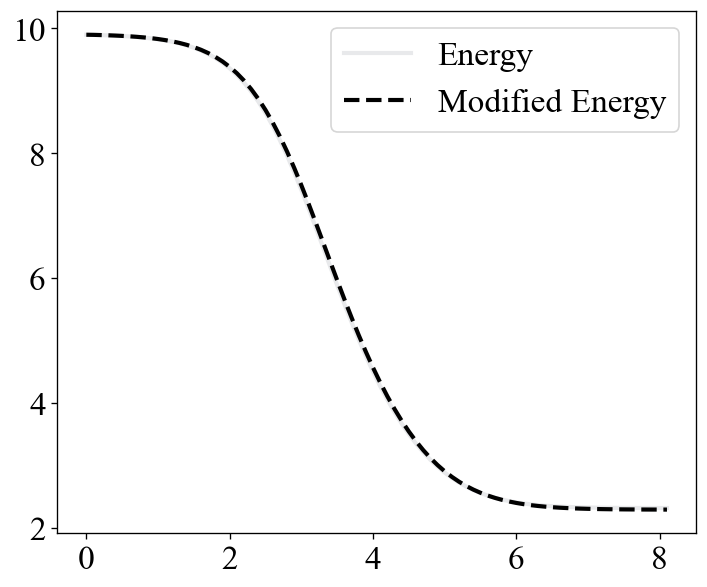

In [28]:
energy_gradient_total = energy_total[:, 0]
energy_non_linear_total = energy_total[:, 1]
energy = energy_gradient_total + energy_non_linear_total

energy_modified_gradient_total = energy_modified_total[:, 0]
energy_modified_nonlinear_total = energy_modified_total[:, 1]
energy_modified = energy_modified_gradient_total + energy_modified_nonlinear_total

# Journal of Computational Physics (Elsevier): Times New Roman for figures
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["mathtext.rm"] = "Times New Roman"

fig, ax = plt.subplots(figsize=(6, 5), dpi=120)
# ax.plot(t_total, energy_gradient_total * dx**2, color="#2E86AB", lw=2, label="Gradient energy")
# ax.plot(t_total, energy_non_linear_total * dx**2, color="#A23B72", lw=2, label="Non-linear energy")
# ax.plot(t_total[:], energy[:] * dx**2, color="#29cfcc", lw=2.5, label="Energy")
# ax.plot(t_total[:], energy_modified[:] * dx**2, color="red", lw=2.5, linestyle="--", label="Modified Energy")
ax.plot(t_total[:], energy[:] * dx**2, color="#e8e9eb", lw=2.5, label="Energy")
ax.plot(t_total[:], energy_modified[:] * dx**2, color="black", lw=2.5, linestyle="--", label="Modified Energy")

from matplotlib.ticker import FuncFormatter, MultipleLocator

config_title = f"{save_path}/{method}/{method}_AC_comparison_Nx{Nx}_Ny{Ny}_dt{dt}_eps{eps:.4f}_T{T}_bc{bc}_energy_case3"


label_font = {"fontsize": 20, "fontfamily": "Times New Roman"}
# ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x/1e2:.0f}"))
# ax.yaxis.set_major_locator(MultipleLocator(100))
# ax.text(-0.01, 1.02, r"$\times\,10^{2}$",
#         transform=ax.transAxes,
#         fontsize=20,
#         fontfamily="Times New Roman",
#         va="bottom")
ax.tick_params(axis="both", labelsize=20)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily("Times New Roman")
# ax.legend(loc="best", frameon=True, prop={"family": "serif", "size": 14})
# ax.grid(True, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)
ax.set_xticks([0, 2, 4, 6, 8])
ax.set_yticks([2, 4, 6, 8, 10])
fig.tight_layout()

ax.legend(loc="best", frameon=True, prop={"family": "Times New Roman", "size": 20})

if save:
    energy_save_path = f"{config_title}.pdf"
    fig.savefig(energy_save_path, bbox_inches="tight")
    print(f"Figure saved to {energy_save_path}")
plt.show()

8.099999999999987


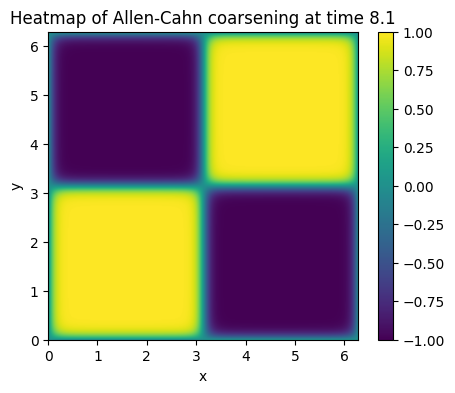

In [17]:
print(t_total[-1])
my_solver.display(u_total[-1], [a_x, b_x, a_y, b_y], t_total[-1], save=False)

### Generate animation

In [18]:
import matplotlib.animation as animation

In [19]:
# utils.generate_anime(u_total, t_total, [a_x, b_x, a_y, b_y], save=True)

In [20]:
# fig, ax = plt.subplots()
# cax = ax.imshow(u_total[0], cmap='viridis', origin='lower')
# fig.colorbar(cax)

# def update(frame):
#     cax.set_data(u_total[frame])
#     ax.set_title(f'Current time: {round(t_total[frame], 5)}')
#     return [cax]

# ani = animation.FuncAnimation(fig, update, frames=len(u_total), blit=True)

# # Save as GIF
# ani.save('Natural Timestepping Cahn-Hilliard Coarsening.gif', writer='pillow', fps=10)